# Sprint 2 - Analise Exploratoria (EDA) e SQL

Objetivo: extrair metricas descritivas e investigar padroes de negocio a
partir do banco relacional gerado na Sprint 1 (`database/ecommerce.db`),
usando estatistica descritiva, consultas SQL com Joins/Window Functions/
Group By, analise de correlacao e deteccao de outliers.


In [1]:
import sys
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "scripts"))

import eda
import run_sql_queries as sqlq

DB_PATH = eda.DB_PATH
conn = sqlite3.connect(DB_PATH)
df = eda.load_vendas(conn)
df.head()


,ID_Transacao,ID_Cliente,ID_Produto,Data_Venda,Valor_Unitario,Quantidade,Faturamento,Cidade,Estado,Pais,Metodo_Pagamento,Status_Pedido,Nome_Produto,Categoria_Produto
0,TRX002095,CLI01104,PRD0001,2025-07-12,268.33,1,268.33,Recife,PE,Brasil,Pix,Em Processamento,Aspirador de Pó,Casa
1,TRX001427,CLI00020,PRD0001,2025-03-22,30.38,1,30.38,Recife,PE,Brasil,Cartao De Debito,Concluido,Aspirador de Pó,Casa
2,TRX001216,CLI00279,PRD0001,2025-12-15,2875.54,1,2875.54,Fortaleza,CE,Brasil,Cartao De Credito,Concluido,Aspirador de Pó,Casa
3,TRX001739,CLI00079,PRD0001,2025-01-30,1864.12,5,9320.60,Brasília,DF,Brasil,Cartao De Credito,Em Processamento,Aspirador de Pó,Casa
4,TRX003521,CLI00273,PRD0001,2025-04-14,2868.65,4,11474.60,Belo Horizonte,MG,Brasil,Cartao De Credito,Cancelado,Aspirador de Pó,Casa


## 1. Estatisticas descritivas

In [2]:
numericas, categoricas = eda.estatisticas_descritivas(df)
numericas


,Valor_Unitario,Quantidade,Faturamento
count,5874.00,5874.00,5874.00
mean,1762.03,3.03,5339.41
std,1003.21,1.40,4133.54
min,15.27,1.00,15.51
25%,887.01,2.00,1987.74
50%,1776.37,3.00,4292.79
75%,2625.64,4.00,7997.92
max,3499.62,5.00,17486.30


In [3]:
categoricas


,Categoria_Produto,Metodo_Pagamento,Status_Pedido,Estado
count,5874,5874,5874,5874
unique,5,5,4,10
top,Livros,Pix,Concluido,AM
freq,1244,1946,2301,623


**Leitura rapida:** o faturamento medio por venda (ticket) fica proximo de
R$ 5.339, com bastante dispersao (desvio padrao de ~R$ 4.134), refletindo o
mix de produtos de baixo e alto valor. `Categoria_Produto`, `Metodo_Pagamento`,
`Status_Pedido` e `Estado` ja chegam padronizados (sem variacoes de
maiusculas/minusculas) por causa do tratamento feito na Sprint 1.


## 2. Correlacao entre variaveis numericas

In [4]:
corr = eda.matriz_correlacao(df)
corr


,Valor_Unitario,Quantidade,Faturamento
Valor_Unitario,1.000,-0.003,0.731
Quantidade,-0.003,1.000,0.590
Faturamento,0.731,0.590,1.000


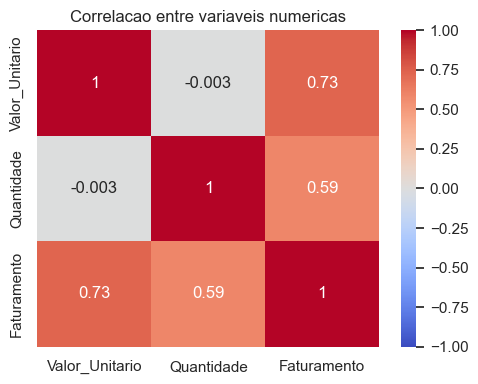

In [5]:
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlacao entre variaveis numericas")
plt.tight_layout()
plt.show()


**Leitura rapida:** `Faturamento` correlaciona moderadamente com
`Valor_Unitario` (0.73) e com `Quantidade` (0.59) — esperado, ja que
`Faturamento = Valor_Unitario * Quantidade`. Ja `Valor_Unitario` e
`Quantidade` sao praticamente independentes entre si (-0.003), ou seja,
produtos mais caros nao sao comprados em quantidades sistematicamente
menores ou maiores neste dataset.


## 3. Deteccao de outliers (metodo IQR)

In [6]:
resumo = []
for col in eda.NUMERIC_COLS:
    outliers = eda.detectar_outliers_iqr(df, col)
    resumo.append({
        "coluna": col,
        "qtd_outliers": len(outliers),
        "pct_outliers": round(100 * len(outliers) / len(df), 2),
    })
pd.DataFrame(resumo)


,coluna,qtd_outliers,pct_outliers
0,Valor_Unitario,0,0.00
1,Quantidade,0,0.00
2,Faturamento,29,0.49


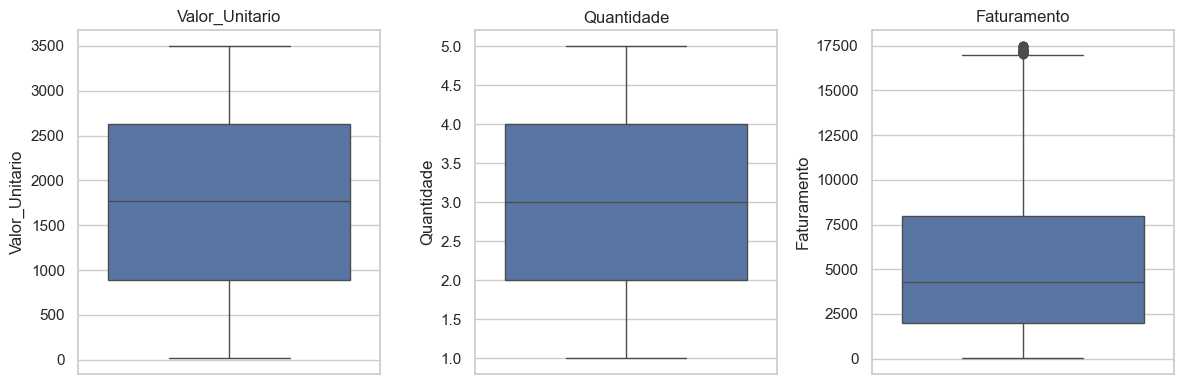

In [7]:
fig, axes = plt.subplots(1, len(eda.NUMERIC_COLS), figsize=(12, 4))
for ax, col in zip(axes, eda.NUMERIC_COLS):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [8]:
eda.detectar_outliers_iqr(df, "Faturamento").sort_values("Faturamento", ascending=False).head(10)


,ID_Transacao,ID_Cliente,ID_Produto,Data_Venda,Valor_Unitario,Quantidade,Faturamento,Cidade,Estado,Pais,Metodo_Pagamento,Status_Pedido,Nome_Produto,Categoria_Produto
4278,TRX003642,CLI00896,PRD0019,2025-11-03,3497.26,5,17486.30,Fortaleza,CE,Brasil,Cartao De Credito,Em Processamento,Quadrinho Clássico,Livros
808,TRX000058,CLI01003,PRD0004,2025-10-06,3496.17,5,17480.85,Manaus,AM,Brasil,Pix,Concluido,Liquidificador,Casa
2040,TRX001636,CLI00347,PRD0009,2025-12-30,3495.66,5,17478.30,Rio De Janeiro,RJ,Brasil,Pix,Cancelado,"Smart TV 50""",Eletrônicos
2064,TRX005579,CLI00868,PRD0009,2025-04-28,3494.43,5,17472.15,Belo Horizonte,MG,Brasil,Cartao De Credito,Cancelado,"Smart TV 50""",Eletrônicos
1914,TRX000019,CLI00151,PRD0009,2025-05-06,3486.40,5,17432.00,Manaus,AM,Brasil,Cartao De Credito,Devolvido,"Smart TV 50""",Eletrônicos
3499,TRX001360,CLI01072,PRD0016,2025-09-15,3482.27,5,17411.35,Belo Horizonte,MG,Brasil,Cartao De Credito,Concluido,Biografia,Livros
5130,TRX000144,CLI00480,PRD0022,2025-06-14,3477.29,5,17386.45,Belo Horizonte,MG,Brasil,Pix,Devolvido,Camiseta Básica,Moda
1574,TRX004219,CLI00393,PRD0007,2025-08-10,3474.36,5,17371.80,Curitiba,PR,Brasil,Cartao De Credito,Concluido,Fone Bluetooth,Eletrônicos
4404,TRX005607,CLI00990,PRD0019,2025-11-12,3463.25,5,17316.25,Manaus,AM,Brasil,Cartao De Credito,Devolvido,Quadrinho Clássico,Livros
4844,TRX004117,CLI00434,PRD0021,2025-03-02,3456.45,5,17282.25,Rio De Janeiro,RJ,Brasil,Cartao De Credito,Devolvido,Calça Jeans,Moda


**Leitura rapida:** `Valor_Unitario` e `Quantidade` nao apresentam outliers
pelo criterio IQR (faixas de geracao dos dados sao limitadas e uniformes).
Ja `Faturamento` — por ser o produto das duas variaveis — tem ~0,5% de
vendas atipicas (tickets muito altos, tipicamente valor unitario alto
combinado com quantidade alta). Vale monitorar essas transacoes na analise
de fraude/qualidade antes de qualquer modelagem preditiva futura.


## 4. Consultas SQL (Joins, Window Functions, Group By)

As consultas completas estao versionadas em `sql/consultas_sprint2.sql` e
podem ser executadas de forma automatizada com
`python scripts/run_sql_queries.py` (exporta cada resultado para
`reports/sql/`). Abaixo, cada uma e reexecutada e comentada.


In [9]:
consultas = sqlq.carregar_consultas()
list(consultas.keys())


['faturamento_por_categoria',
 'top_clientes',
 'faturamento_mensal',
 'ticket_medio_por_estado',
 'top_produtos_por_categoria',
 'rfm_clientes',
 'distribuicao_status_pedido']

### 4.1 Faturamento por categoria (GROUP BY + JOIN + RANK)

In [10]:
pd.read_sql(consultas["faturamento_por_categoria"], conn)


,Categoria_Produto,qtd_vendas,faturamento_total,ticket_medio,ranking_faturamento
0,Livros,1244,6556892.78,5270.81,1
1,Eletrônicos,1188,6382741.86,5372.68,2
2,Moda,1203,6304760.84,5240.87,3
3,Esporte,1135,6166445.04,5432.99,4
4,Casa,1104,5952853.72,5392.08,5


Livros lidera o faturamento total, mas as cinco categorias estao bem equilibradas — nenhuma concentra mais de ~20% da receita.

### 4.2 Top 10 clientes por faturamento (Window Function: SUM/RANK OVER)

In [11]:
pd.read_sql(consultas["top_clientes"], conn)


,ID_Cliente,faturamento_total,qtd_pedidos,pct_do_faturamento_total,ranking
0,CLI01050,92203.99,14,0.29,1
1,CLI01072,82671.24,11,0.26,2
2,CLI00990,82606.23,9,0.26,3
3,CLI00447,81943.06,11,0.26,4
4,CLI00143,80572.82,9,0.26,5
5,CLI00584,78068.72,10,0.25,6
6,CLI01056,74636.22,9,0.24,7
7,CLI00394,74596.71,10,0.24,8
8,CLI00299,74234.52,13,0.24,9
9,CLI00927,72380.32,9,0.23,10


A base de clientes e pulverizada: o cliente que mais compra responde por menos de 0,3% do faturamento total, sinal de baixa concentracao de receita (nao ha dependencia de poucos clientes-chave).

### 4.3 Faturamento mensal com media movel (Window Function: LAG/AVG OVER)

In [12]:
faturamento_mensal = pd.read_sql(consultas["faturamento_mensal"], conn)
faturamento_mensal


,mes,faturamento,variacao_absoluta,variacao_pct,media_movel_3m
0,2025-01,2548649.84,NaN,NaN,2548649.84
1,2025-02,2254360.84,-294289.00,-11.55,2401505.34
2,2025-03,2675612.08,421251.24,18.69,2492874.25
3,2025-04,2515579.42,-160032.66,-5.98,2481850.78
4,2025-05,2588824.33,73244.91,2.91,2593338.61
5,2025-06,2503881.97,-84942.36,-3.28,2536095.24
6,2025-07,2764913.58,261031.61,10.43,2619206.63
7,2025-08,2800148.88,35235.30,1.27,2689648.14
8,2025-09,2464286.22,-335862.66,-11.99,2676449.56
9,2025-10,3083792.37,619506.15,25.14,2782742.49


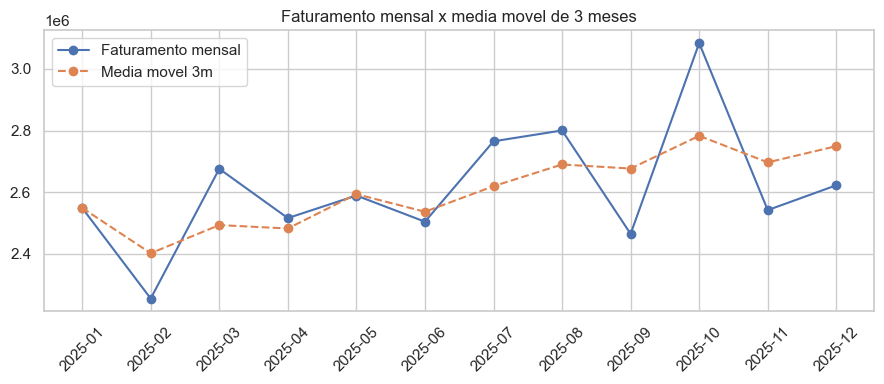

In [13]:
plt.figure(figsize=(9, 4))
plt.plot(faturamento_mensal["mes"], faturamento_mensal["faturamento"], marker="o", label="Faturamento mensal")
plt.plot(faturamento_mensal["mes"], faturamento_mensal["media_movel_3m"], marker="o", linestyle="--", label="Media movel 3m")
plt.xticks(rotation=45)
plt.legend()
plt.title("Faturamento mensal x media movel de 3 meses")
plt.tight_layout()
plt.show()


Nao ha uma tendencia forte de crescimento ou sazonalidade marcante ao longo de 2025 — o faturamento oscila dentro de uma faixa relativamente estavel, compativel com a natureza simulada e aleatoria do dataset.

### 4.4 Ticket medio por estado (JOIN + GROUP BY)

In [14]:
pd.read_sql(consultas["ticket_medio_por_estado"], conn)


,Estado,clientes_unicos,qtd_vendas,faturamento_total,ticket_medio
0,AM,495,623,3426671.33,5500.28
1,MG,471,612,3390670.40,5540.31
2,DF,461,606,3220233.78,5313.92
3,CE,470,597,3203896.59,5366.66
4,PE,449,577,3109285.87,5388.71
5,RJ,468,587,3089541.62,5263.27
6,RS,448,575,3067360.10,5334.54
7,BA,457,574,2981730.91,5194.65
8,SP,454,551,2939212.79,5334.32
9,PR,457,572,2935090.85,5131.28


Os 10 estados simulados apresentam ticket medio e volume de vendas muito proximos entre si — nao ha uma regiao clara de maior valor agregado.

### 4.5 Top 3 produtos por categoria (Window Function: RANK com PARTITION BY)

In [15]:
pd.read_sql(consultas["top_produtos_por_categoria"], conn)


,Categoria_Produto,Nome_Produto,qtd_total,faturamento_total,ranking_categoria
0,Casa,Jogo de Panelas,707,1306716.24,1
1,Casa,Kit Cama,674,1213824.88,2
2,Casa,Aspirador de Pó,658,1177941.38,3
3,Eletrônicos,"Smart TV 50""",775,1442972.76,1
4,Eletrônicos,Fone Bluetooth,739,1310532.68,2
5,Eletrônicos,Notebook Prime,698,1247685.52,3
6,Esporte,Bola de Futebol,755,1302743.31,1
7,Esporte,Corda de Pular,698,1261649.17,2
8,Esporte,Tapete de Yoga,676,1238942.92,3
9,Livros,Biografia,792,1424620.55,1


Identifica os produtos-carro-chefe de cada categoria, uteis para priorizacao de estoque/marketing.

### 4.6 Base RFM por cliente (Recencia, Frequencia, Valor + NTILE)

In [16]:
rfm = pd.read_sql(consultas["rfm_clientes"], conn)
rfm.head(10)


,ID_Cliente,ultima_compra,frequencia,valor_total,recencia_dias,quartil_valor
0,CLI01050,2025-12-18 00:00:00,14,92203.99,13,1
1,CLI01072,2025-12-19 00:00:00,11,82671.24,12,1
2,CLI00990,2025-11-28 00:00:00,9,82606.23,33,1
3,CLI00447,2025-10-29 00:00:00,11,81943.06,63,1
4,CLI00143,2025-11-13 00:00:00,9,80572.82,48,1
5,CLI00584,2025-12-08 00:00:00,10,78068.72,23,1
6,CLI01056,2025-12-03 00:00:00,9,74636.22,28,1
7,CLI00394,2025-12-30 00:00:00,10,74596.71,1,1
8,CLI00299,2025-12-22 00:00:00,13,74234.52,9,1
9,CLI00927,2025-12-22 00:00:00,9,72380.32,9,1


Essa base (recencia em dias, frequencia de compras, valor total e quartil de valor) e o ponto de partida para a segmentacao RFM de clientes, uma das perguntas estrategicas do desafio — sera aprofundada nas proximas sprints.

### 4.7 Distribuicao de status do pedido (GROUP BY)

In [17]:
pd.read_sql(consultas["distribuicao_status_pedido"], conn)


,Status_Pedido,qtd,pct
0,Concluido,2301,39.17
1,Em Processamento,1217,20.72
2,Devolvido,1207,20.55
3,Cancelado,1149,19.56


Cerca de 40% dos pedidos sao concluidos; cancelamentos e devolucoes somados representam ~40% das vendas — uma taxa alta que merece investigacao de causa raiz em uma analise de negocio real.

## Conclusoes da Sprint 2

- As variaveis numericas nao possuem nulos (tratados na Sprint 1) e tem
  distribuicoes coerentes com a geracao simulada dos dados.
- `Faturamento` correlaciona com `Valor_Unitario` e `Quantidade`, como
  esperado pela propria formula de calculo; nao ha colinearidade entre as
  duas variaveis de entrada.
- Poucos outliers (~0,5%) concentrados em `Faturamento`, associados a
  vendas de alto valor unitario combinado com alta quantidade.
- Receita bem distribuida entre categorias, estados e clientes — sem
  concentracao de risco em poucos elementos.
- A base RFM (`sql/consultas_sprint2.sql`, consulta `rfm_clientes`) fica
  pronta para a segmentacao de clientes solicitada no desafio.
- A taxa combinada de cancelamento/devolucao (~40%) e um ponto de atencao
  para as proximas sprints de storytelling.


In [18]:
conn.close()
